# Background

Retail companies are facing inventory challenges due to the fluctuation of demand from time to time. They may rely on system calculation or manual calculation from experienced staff. Usually, the past sales data would be used for estimating the future demand. In fact, the sales data might be affected by factors like:
- Stockout → sales suddenly decline → reflected as a drop in sales.
- Seasonal trend → sales rise and decline periodically.
- Marketing Activities (discounts/promotions) → sales suddenly rise → reflected as an increase in sales.

The dataset simulates a retail store's sales data for a specific category, and there are **no seasonal trends** or **marketing activities**.

**Dataset Detail:**
- sales1: numeric - the sales data in Qty of week1
- ...
- sales12: numeric - the sales data in Qty of week12
- Latest_sales: numeric - the sales data in Qty of week13

**Objective:** To train a machine learning model to predict the regular demand because the accuracy from ordinary system calculation is poor, requires manual ordering by experienced staff.

**Expected Outcome:** Reduce manual ordering time by using the model prediction result.

---

# 1. Data Preprocessing

In [21]:
# import library for data processing
import numpy as np
import pandas as pd
import os

# import library for visualisation
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(color_codes=True)

Zeros or sharp drops in sales might be caused by stockout. We assume the database is operating normally.

In [22]:
# loading dataset
df = pd.read_csv("dataset/sales_data.csv")
print("The number of rows and columns of the dataset:", df.shape)
print(df.to_string())

The number of rows and columns of the dataset: (472, 13)
     sales1  sales2  sales3  sales4  sales5  sales6  sales7  sales8  sales9  sales10  sales11  sales12  Latest_sales
0        17      68      45      60      50      22      89      53      22       83       51       50            55
1        23      29      24      15      19      27      32      27      38       26       33       19            34
2        47      27      39      21      18      36      60      47      31        0        0        0            48
3        41      72      52      64      84      69      69      86      80       78       82        0            82
4        50      22      89      53      22      83      51      50      17       41       35       16            51
5        27     100      24     105      23     105      27     148      14       56       26      120            61
6        61      81      84      71     106      71      97      86     109      121       97        0           102
7      

In [23]:
# display the data types
print("Data types:")
print(df.dtypes.to_string())

Data types:
sales1          int64
sales2          int64
sales3          int64
sales4          int64
sales5          int64
sales6          int64
sales7          int64
sales8          int64
sales9          int64
sales10         int64
sales11         int64
sales12         int64
Latest_sales    int64


In [24]:
# search for missing values
print("Missing values count:", df.isnull().sum().sum())
print(df.isnull().sum().to_string())

Missing values count: 0
sales1          0
sales2          0
sales3          0
sales4          0
sales5          0
sales6          0
sales7          0
sales8          0
sales9          0
sales10         0
sales11         0
sales12         0
Latest_sales    0


Only use rows with sales data >= 3 to ensure enough data for training.
It is suggested to find out why the stockout issue occurs for a long period of time.

In [25]:
# filter rows with 0 qty in 'sales1' to 'sales12' more than n times
zero_qty_cols = df.loc[:, 'sales1':'sales12']
n = 10 # threshold
df_zero_qty = df[(zero_qty_cols == 0).sum(axis=1) >= n] # filter >= n times with 0 qty
print(f"Number of rows with 0 qty >= {n} times:", df_zero_qty.shape[0])
print(df_zero_qty.to_string())

# drop thoes rows
df = df.drop(df_zero_qty.index)
print("The number of rows and columns of the dataset after dropping rows:", df.shape)

Number of rows with 0 qty >= 10 times: 13
     sales1  sales2  sales3  sales4  sales5  sales6  sales7  sales8  sales9  sales10  sales11  sales12  Latest_sales
28        0       0       0       0       0       0       0       0       0        0        0        0             0
34       19      20       0       0       0       0       0       0       0        0        0        0            20
50        0       0       0       0       0       0       0       0       0        0        0       16            16
85        0       0       0       0       0       0       0       0       0        0        0        0             0
134       0       0       0       0       0       0       0       0       0        0        0        0             0
171       0       0       0       0       0       0       0       0       0        0        0       15            15
227       0       0       0       0       0       0       0       0       0        0        0        0             0
268       0       0   

Visualize sales history

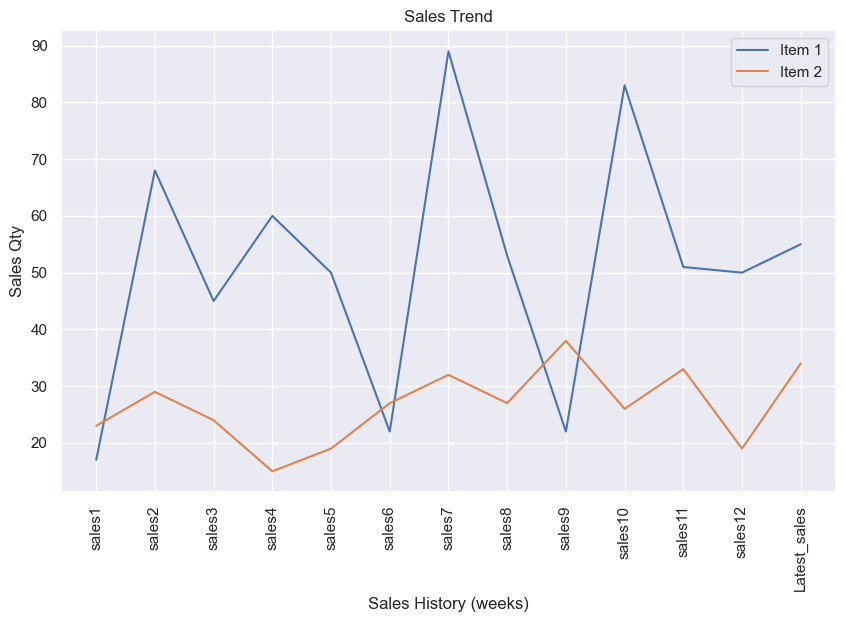

In [26]:
# number of lines to plot
n = 2
sales_cols = df.loc[:, 'sales1':].columns
plt.figure(figsize=(10, 6))
for i in range(n):
    plt.plot(sales_cols, df.loc[i, sales_cols], label=f'Item {i+1}')
plt.title('Sales Trend')
plt.xlabel('Sales History (weeks)')
plt.ylabel('Sales Qty')
plt.xticks(rotation=90)
plt.legend()
plt.show()

This would be a **supervised machine learning** task. 'Latest_sales' is the target column (y hat).

Feature selection
- Using all the sales data as features to overcome the sudden drop or pump in sales which might affect the prediction result.

In [27]:
# feature selection
X = df.loc[:, 'sales1':'sales12']
y = df['Latest_sales']

# mean of the qty excluding 0 in qty
X['Mean'] = df.loc[:, 'sales1':'sales12'].replace(0, np.nan).mean(axis=1)
# std of the qty excluding 0 in qty
X['STD'] = df.loc[:, 'sales1':'sales12'].replace(0, np.nan).std(axis=1)

# replace nan with 0
X.fillna(0, inplace=True)

# test train split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=0)

# display the dataset after splitting
print("The number of rows and columns of the training dataset:", X_train.shape)
print(X_train.to_string())
print("The number of rows and columns of the testing dataset:", X_test.shape)
print(X_test.to_string())

The number of rows and columns of the training dataset: (413, 14)
     sales1  sales2  sales3  sales4  sales5  sales6  sales7  sales8  sales9  sales10  sales11  sales12       Mean        STD
254      57      34      62      48      46      41      46      82       0        0        0        0  52.000000  14.918828
177      22      18      21      11      20      22      33      30      23       11       41       12  22.000000   9.095453
378      15      61      32      21      32      35      34      53      22       33       12       17  30.583333  14.792248
354      35      90      73      79      96      65      41      86      35       76       47       48  64.250000  22.136457
194      13      46      24      13      27      29      52      36       0        0       46        5  29.100000  15.891647
343      50      61      30      87      22      60     108      25      48       39       59       37  52.166667  25.372975
427      32       6      25      49      37      24      10

---

# 2. Model Training

Here we use Random Forest Regressor to train.

In [28]:
# model
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import r2_score, mean_absolute_percentage_error

Evaluation metrics used to search for the best model during training:
- MAPE (Mean Absolute Percentage Error): lower the better

Parameters tuning:
- min_samples_split
- max_depth

Start adjusting parameters: min_samples_split, max_depth...
current best model: min_sample_split: 2, max_depth: 3; MAPE: 0.09
Current best model: min_sample_split: 2, max_depth: 4; MAPE: 0.09
Current best model: min_sample_split: 2, max_depth: 5; MAPE: 0.08
Current best model: min_sample_split: 2, max_depth: 9; MAPE: 0.08
Tested min_samples_split: 2, max_depth: 3 to 15
Tested min_samples_split: 3, max_depth: 3 to 15
Tested min_samples_split: 4, max_depth: 3 to 15
Tested min_samples_split: 5, max_depth: 3 to 15
Tested min_samples_split: 6, max_depth: 3 to 15
Tested min_samples_split: 7, max_depth: 3 to 15
Tested min_samples_split: 8, max_depth: 3 to 15
Tested min_samples_split: 9, max_depth: 3 to 15
Tested min_samples_split: 10, max_depth: 3 to 15

Lowest MAPE: min_samples_split: 2, max_depth: 9
The Mean Squared Error: 22.27
The R-Squared: 0.94
The Mean Absolute Error: 3.63
The Mean Absolute Percentage Error: 0.08


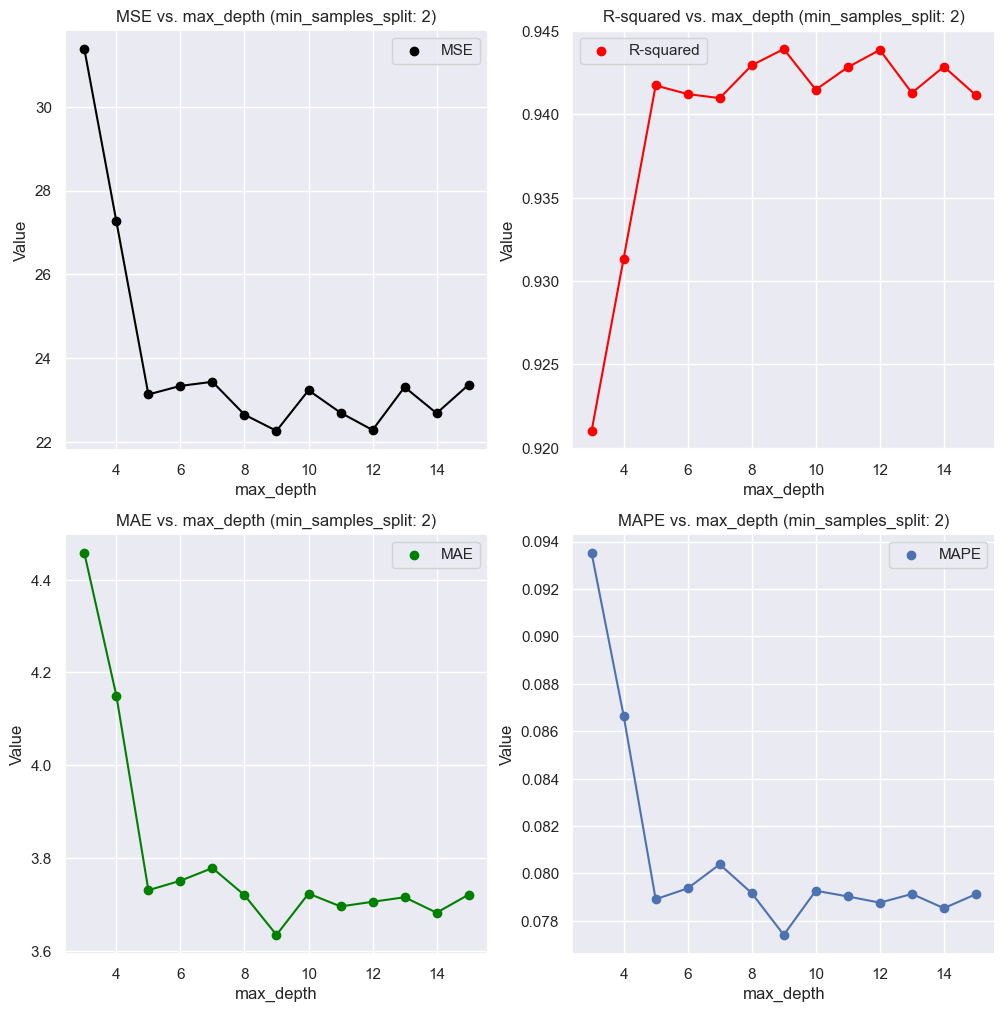

In [29]:
# store the evaluation metrics for each training with different hyperparameters
mse_list = []
r2_list = []
mae_list = []
mape_list = []

# count the number of models tested
i = 0

print("Start adjusting parameters: min_samples_split, max_depth...")
for split in range(2, 10 + 1):
    depth = 3

    model_rf = RandomForestRegressor(n_estimators=100, random_state=42, min_samples_split=split, max_depth=depth)
    model_rf.fit(X_train, y_train)

    y_pred = model_rf.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)

    mse_list.append(mse)
    r2_list.append(r2)
    mae_list.append(mae)
    mape_list.append(mape)

    # search for best model based on MAPE (lower is better)
    if mape == min(mape_list):
        best_split = split
        best_depth = depth
        best_mse = mse_list[i]
        best_r2 = r2_list[i]
        best_mae = mae_list[i]
        best_mape = mape_list[i]
        print(f"current best model: min_sample_split: {best_split}, max_depth: {best_depth}; MAPE: {best_mape:.2f}")

    i = i + 1

    # count the number of depth tested in 1 loop, for plotting
    depth_list = [depth]

    for depth in range(4, 15 + 1):
        model_rf = RandomForestRegressor(n_estimators=100, random_state=42, min_samples_split=split, max_depth=depth)
        model_rf.fit(X_train, y_train)

        y_pred = model_rf.predict(X_test)

        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        mape = mean_absolute_percentage_error(y_test, y_pred)

        mse_list.append(mse)
        r2_list.append(r2)
        mae_list.append(mae)
        mape_list.append(mape)

        # search for best model based on MAPE (lower is better)
        if mape == min(mape_list):
            best_split = split
            best_depth = depth
            best_mse = mse_list[i]
            best_r2 = r2_list[i]
            best_mae = mae_list[i]
            best_mape = mape_list[i]
            print(f"Current best model: min_sample_split: {best_split}, max_depth: {best_depth}; MAPE: {best_mape:.2f}")

        i = i + 1

        depth_list.append(depth)

    print(f"Tested min_samples_split: {split}, max_depth: {depth_list[0]} to {depth_list[-1]}")

# best model evaluation by MAPE
print(f"\nLowest MAPE: min_samples_split: {best_split}, max_depth: {best_depth}")
print(f"The Mean Squared Error: {best_mse:.2f}")
print(f"The R-Squared: {best_r2:.2f}")
print(f"The Mean Absolute Error: {best_mae:.2f}")
print(f"The Mean Absolute Percentage Error: {best_mape:.2f}")

# Visualize the evaluation of the best split and depth model
plt_split = (best_split - 2) * len(depth_list)

# Create a 2x2 grid of subplots
fig, axs = plt.subplots(2, 2, figsize=(12, 12))

# mse plot
plt_mse = mse_list[plt_split: plt_split + len(depth_list)]
axs[0, 0].plot(depth_list, plt_mse, color='black')
axs[0, 0].scatter(depth_list, plt_mse, color='black', label='MSE')
axs[0, 0].legend()
axs[0, 0].set_title(f"MSE vs. max_depth (min_samples_split: {best_split})")

# r2 plot
plt_r2 = r2_list[plt_split: plt_split + len(depth_list)]
axs[0, 1].plot(depth_list, plt_r2, color='red')
axs[0, 1].scatter(depth_list, plt_r2, color='red', label='R-squared')
axs[0, 1].legend()
axs[0, 1].set_title(f"R-squared vs. max_depth (min_samples_split: {best_split})")

# mae plot
plt_mae = mae_list[plt_split: plt_split + len(depth_list)]
axs[1, 0].plot(depth_list, plt_mae, color='green')
axs[1, 0].scatter(depth_list, plt_mae, color='green', label='MAE')
axs[1, 0].legend()
axs[1, 0].set_title(f"MAE vs. max_depth (min_samples_split: {best_split})")

# mape plot
plt_mape = mape_list[plt_split: plt_split + len(depth_list)]
axs[1, 1].plot(depth_list, plt_mape)
axs[1, 1].scatter(depth_list, plt_mape, label='MAPE')
axs[1, 1].legend()
axs[1, 1].set_title(f"MAPE vs. max_depth (min_samples_split: {best_split})")

# Add titles and labels
for ax in axs.flat:
    ax.set(xlabel='max_depth', ylabel='Value')

plt.show()

From the above searching, the **MAPE** is the lowest at split=2 & depth=9. These parameters would be used for model training.

Why MAPE?
- The dataset contains low sales products and high sales products. Using MAPE targets minimizing the residual of low sales. For example, a product with sales 10 pcs where the model predicts 20 pcs, which is only 10 pcs more → +100% difference. On the other hand, a product with sales 100 pcs where the model predicts 10 pcs more → +10% difference.

Let's move on to use the above parameters for training.

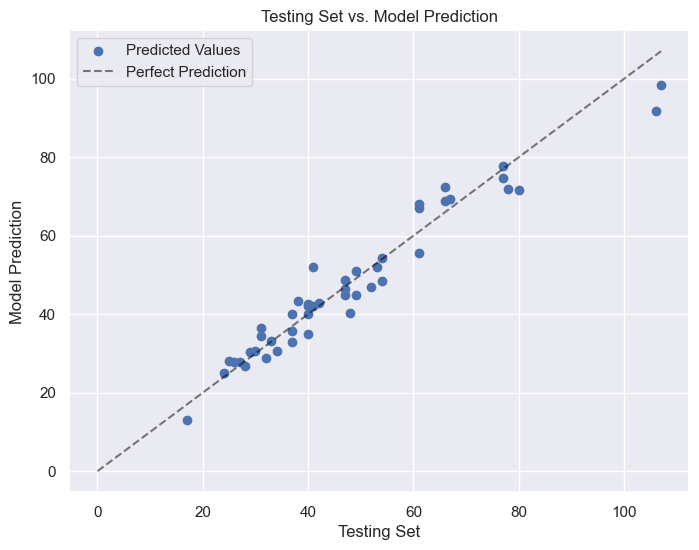

Model Evaluation of normal dataset:
Mean Squared Error: 22.27
R-squared: 0.94
Mean Absolute Error: 3.63
Mean Absolute Percentage Error: 0.08


In [30]:
model_rf = RandomForestRegressor(n_estimators=100, random_state=42, min_samples_split=best_split, max_depth=best_depth)

model_rf.fit(X_train, y_train)

y_pred = model_rf.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

# Visualize the predictions
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, label='Predicted Values')
# add a plot for perfect prediction
plt.plot([0, max(y_test)], [0, max(y_test)], color='black', linestyle='--', label='Perfect Prediction', alpha=0.5)
plt.legend()
plt.xlabel('Testing Set')
plt.ylabel('Model Prediction')
plt.title('Testing Set vs. Model Prediction')
plt.show()

# evaluate the model
print("Model Evaluation of normal dataset:")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Absolute Percentage Error: {mape:.2f}")

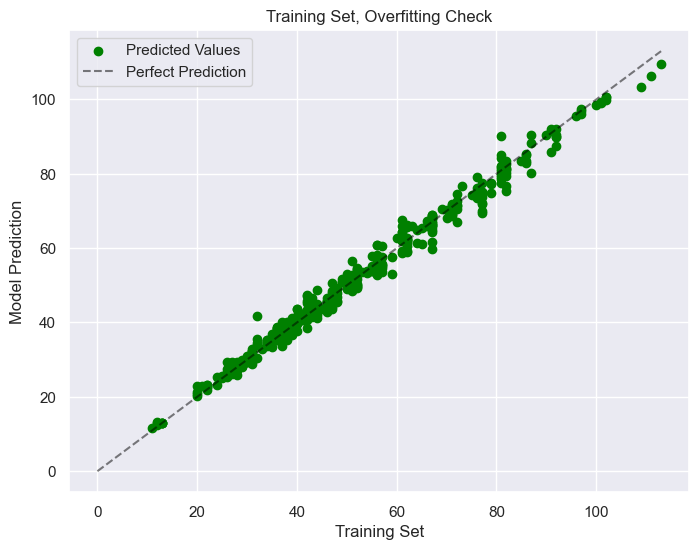

Model Evaluation of training dataset:
Mean Squared Error: 4.78
R-squared: 0.99
Mean Absolute Error: 1.59
Mean Absolute Percentage Error: 0.03


In [31]:
y_pred_train = model_rf.predict(X_train)

mse = mean_squared_error(y_train, y_pred_train)
r2 = r2_score(y_train, y_pred_train)
mae = mean_absolute_error(y_train, y_pred_train)
mape = mean_absolute_percentage_error(y_train, y_pred_train)

# Visualize the predictions
plt.figure(figsize=(8, 6))
plt.scatter(y_train, y_pred_train, color='green', label='Predicted Values')
# add a plot for perfect prediction
plt.plot([0, max(y_train)], [0, max(y_train)], color='black', linestyle='--', label='Perfect Prediction', alpha=0.5)
plt.legend()
plt.xlabel('Training Set')
plt.ylabel('Model Prediction')
plt.title('Training Set, Overfitting Check')
plt.show()

# evaluate the model
print("Model Evaluation of training dataset:")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Absolute Percentage Error: {mape:.2f}")

---

# 3. Model monitoring in practical use

Monitor the model by setting upper and lower limits as an alert in case it goes too far.
- Upper limit = mean + 2 standard deviation
- Lower limit = mean

Once model prediction exceeds threshold will show "Remark" as a signal:
- "Over Estimate": Exceeds upper limit
- "Under Estimate": Exceeds lower limit
- "Not enough data": Sales data less than 3 weeks.

In [32]:
# Merge the prediction back to the test set
df_test = X_test.copy()
df_test['Testing Set'] = y_test
df_test['Model Predicted'] = y_pred
df_test['Difference'] = y_pred / y_test

# find non-zero values
def find_non_zero_values(row):
    cols = df_test.loc[:, 'sales1':'sales12'].columns
    non_zero_values = [row[col] for col in cols if row[col] > 0]
    return non_zero_values

# Calculate the std and mean of the latest non-zero values
def calc_std(row):
    return np.std(row['NonZeroValues'][-6:])

def calc_mean(row):
    return np.mean(row['NonZeroValues'][-6:])

# Apply the function to filter non-zero value to each row
df_test['NonZeroValues'] = df_test.apply(find_non_zero_values, axis=1)

# upper limit and lower limit
df_test['MaxLimit'] = df_test.apply(calc_mean, axis=1) + df_test.apply(calc_std, axis=1) *2 # upper limit = mean + 2std
df_test['MinLimit'] = df_test.apply(calc_mean, axis=1) # lower limit = mean

# Find out if Model Predicted values are out of range
df_test['Remark'] = np.where(df_test['Model Predicted'] > df_test['MaxLimit'], 'Over Estimate',
                             np.where(df_test['Model Predicted'] < df_test['MinLimit'], 'Under Estimate', ''))

# Filter rows with 0 sold qty in 'sales1' to 'sales12' more than n times
qty_data = df_test.loc[:, 'sales1':'sales12']
n = 10
df_zero_qty = df_test[(qty_data == 0).sum(axis=1) >= n]
# Replace the model Estimate with 'Not enough data' for rows with 0 sold qty in 'sales1' to 'sales12' more than n times
df_test.loc[df_zero_qty.index, 'Remark'] = 'Not enough data'

# Sort by Difference
df_test = df_test.sort_values(by='Difference', ascending=False)

print(df_test.to_string())

     sales1  sales2  sales3  sales4  sales5  sales6  sales7  sales8  sales9  sales10  sales11  sales12       Mean        STD  Testing Set  Model Predicted  Difference                                                                  NonZeroValues    MaxLimit   MinLimit          Remark
306      66      23      28      35      86      42      60      38      85       21       31       21  44.666667  23.788207           41        51.950429    1.267084       [66.0, 23.0, 28.0, 35.0, 86.0, 42.0, 60.0, 38.0, 85.0, 21.0, 31.0, 21.0]   88.777644  42.666667                
339      53       3      13      32      38      32      40      32      30       17       26       22  28.166667  13.251644           31        36.557833    1.179285        [53.0, 3.0, 13.0, 32.0, 38.0, 32.0, 40.0, 32.0, 30.0, 17.0, 26.0, 22.0]   42.549160  27.833333                
228      67      17      43      45      37      36      43      40      17       26       30        0  36.454545  14.187062           38        

Save the model for future use.

In [33]:
# save the model final
model_rf = RandomForestRegressor(n_estimators=100, random_state=42, min_samples_split=best_split, max_depth=best_depth)
model_rf.fit(X, y)

print(model_rf.get_params())

import joblib
os.makedirs('model', exist_ok=True)
joblib.dump(model_rf, 'model/model_rf.pkl')

{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 9, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


['model/model_rf.pkl']

---

# 3. Pipeline for future input and prediction

Now we assume there would be new data every week. The pipeline "prediction.py" could use the saved model to predict new input.
1. CSV data generated from database every week with 12 weeks sales history.
2. Run the python script to use the model to predict new input data.
3. User can use the result generated by the model, which is saved as a csv file in "output/prediction.csv".
4. Monitor alert signals by upper and lower limits, retrain the model if the number of alerts increase.

## **prediction.py**

In [34]:
# %%writefile prediction.py

import os
import numpy as np
import pandas as pd
import joblib

def load_model(model_path):

    model_rf = joblib.load(model_path)
    return model_rf

def prepare_features(data):

    X = data.loc[:, 'sales1':'sales12']
    X = X.copy() # aviod SettingWithCopyWarning
    X['Mean'] = data.loc[:, 'sales1':'sales12'].replace(0, np.nan).mean(axis=1)
    X['STD'] = data.loc[:, 'sales1':'sales12'].replace(0, np.nan).std(axis=1)
    X.fillna(0, inplace=True)
    return X

def predict(model, X):

    y_pred = model.predict(X)
    return y_pred

# function to find non-zero values
def find_non_zero_values(row):
    cols = data.loc[:, 'sales1':'sales12'].columns
    non_zero_values = [row[col] for col in cols if row[col] > 0]
    return non_zero_values

# Calculate the std and mean of the latest non-zero values
def calc_std(row):
    return np.std(row['NonZeroValues'][-6:])
def calc_mean(row):
    return np.mean(row['NonZeroValues'][-6:])

def prediction_check(data, y_pred):

    data['Prediction'] = y_pred

    # Apply the function to filter non-zero value to each row
    data['NonZeroValues'] = data.apply(find_non_zero_values, axis=1)

    # upper limit and lower limit
    data['MaxLimit'] = data.apply(calc_mean, axis=1) + data.apply(calc_std, axis=1) *2 # upper limit = mean + 2std
    data['MinLimit'] = data.apply(calc_mean, axis=1) # lower limit = mean

    # Find out if Model Predicted values are out of range
    data['Remark'] = np.where(data['Prediction'] > data['MaxLimit'], 'Over Estimate',
                              np.where(data['Prediction'] < data['MinLimit'], 'Under Estimate', ''))

    # Filter rows with 0 sold qty in 'sales1' to 'sales12' more than n times
    qty_data = data.loc[:, 'sales1':'sales12']
    n = 10
    df_zero_qty = data[(qty_data == 0).sum(axis=1) >= n]
    # Replace the model Estimate with 'Not enough data' for rows with 0 sold qty in 'sales1' to 'sales12' more than n times
    data.loc[df_zero_qty.index, 'Remark'] = 'Not enough data'

    # Remove the NonZeroValues column, L4MaxLimit, and L4MinLimit
    data.drop(['NonZeroValues', 'MaxLimit', 'MinLimit'], axis=1, inplace=True)
    
    return data

# Load the input data
data = pd.read_csv('input/new_sales_data.csv')

# Load the model
model_path = 'model/model_rf.pkl'
model_rf = load_model(model_path)

# preiction path
prediction_path = 'output/prediction.csv'
os.makedirs('output', exist_ok=True)

# Prepare features
X = prepare_features(data)

# Predict
y_pred = predict(model_rf, X)

# Prediction Check
data = prediction_check(data, y_pred)

# Print the completed message
print("Prediction completed.")

# Print the prediction
print(data.to_string())

# Save to csv
data.to_csv(prediction_path, index=False)
print(f"Saved to {prediction_path}")

Prediction completed.
    sales1  sales2  sales3  sales4  sales5  sales6  sales7  sales8  sales9  sales10  sales11  sales12  Prediction          Remark
0       44      74      25      52      40      50      74      18      40       41       48       39   51.470277                
1       58      61      23      51      42      39      29      57      16       54       17       35   45.319347                
2       50      62      61      32      98      55      24      91      57       60       26       42   63.519558                
3       82      49      34      41       5      26      34      65     113       63        0       61   60.287655  Under Estimate
4        0       0       0       0       0      17      14       0       0       18        0        0   19.236468                
5       11      11      16      11       0      26      15       0       0       20       23       17   20.883968                
6       27      67      35      38      72      61      29      68  

---

# 4. Evaluate model performance

After gathering new sales data, use as untrained data to evaluate the model performance.

In [35]:
import os
import numpy as np
import pandas as pd
import joblib

def load_model(model_path):

    model_rf = joblib.load(model_path)
    return model_rf

def prepare_features(data):

    X = data.loc[:, 'sales1':'sales12']
    X = X.copy() # aviod SettingWithCopyWarning
    X['Mean'] = data.loc[:, 'sales1':'sales12'].replace(0, np.nan).mean(axis=1)
    X['STD'] = data.loc[:, 'sales1':'sales12'].replace(0, np.nan).std(axis=1)
    X.fillna(0, inplace=True)
    return X

def predict(model, X):

    y_pred = model.predict(X)
    return y_pred

# function to find non-zero values
def find_non_zero_values(row):
    cols = data.loc[:, 'sales1':'sales12'].columns
    non_zero_values = [row[col] for col in cols if row[col] > 0]
    return non_zero_values

# Calculate the std and mean of the latest non-zero values
def calc_std(row):
    return np.std(row['NonZeroValues'][-6:])
def calc_mean(row):
    return np.mean(row['NonZeroValues'][-6:])

def prediction_check(data, y_pred):

    data['Prediction'] = y_pred

    # Apply the function to filter non-zero value to each row
    data['NonZeroValues'] = data.apply(find_non_zero_values, axis=1)

    # upper limit and lower limit
    data['MaxLimit'] = data.apply(calc_mean, axis=1) + data.apply(calc_std, axis=1) *2 # upper limit = mean + 2std
    data['MinLimit'] = data.apply(calc_mean, axis=1) # lower limit = mean

    # Find out if Model Predicted values are out of range
    data['Remark'] = np.where(data['Prediction'] > data['MaxLimit'], 'Over Estimate',
                              np.where(data['Prediction'] < data['MinLimit'], 'Under Estimate', ''))

    # Filter rows with 0 sold qty in 'sales1' to 'sales12' more than n times
    qty_data = data.loc[:, 'sales1':'sales12']
    n = 10
    df_zero_qty = data[(qty_data == 0).sum(axis=1) >= n]

    # Replace the model Estimate with 'Not enough data' for rows with 0 sold qty in 'sales1' to 'sales12' more than n times
    data.loc[df_zero_qty.index, 'Remark'] = 'Not enough data'

    return data

# Load the input data
data = pd.read_csv('evaluate/evaluation_data.csv')

# Load the model
model_path = 'model/model_rf.pkl'
model_rf = load_model(model_path)

# preiction path
prediction_path = 'evaluate/evaluation_prediction.csv'
os.makedirs('evaluate', exist_ok=True)

# Prepare features
X = prepare_features(data)

# Predict
y_pred = predict(model_rf, X)

# Prediction Check
data = prediction_check(data, y_pred)

# Print the completed message
print("Prediction completed.")

# Print the prediction
print(data.to_string())

# Save to csv
data.to_csv(prediction_path, index=False)
print(f"Saved to {prediction_path}")

Prediction completed.
     sales1  sales2  sales3  sales4  sales5  sales6  sales7  sales8  sales9  sales10  sales11  sales12  Latest_sales  System_calc  Prediction                                                                 NonZeroValues    MaxLimit   MinLimit           Remark
0        48      49       6      26      17      40       3       0       0        0        0        0            39    28.695652   36.175457                                      [48.0, 49.0, 6.0, 26.0, 17.0, 40.0, 3.0]   57.140254  23.500000                 
1        34      39      34      20      26       0       0       0       0        0        0        0            39    26.900000   36.766864                                                [34.0, 39.0, 34.0, 20.0, 26.0]   44.081840  30.600000                 
2        21      62      47      20      39      60      12      11      51       34       34       17            40    42.250000   41.482329      [21.0, 62.0, 47.0, 20.0, 39.0, 60.0, 12.0, 11.0, 51

Residual plot function

In [36]:
def remove_zero_qty_rows(data, n):
    zero_qty_cols = data.loc[:, 'sales1':'sales12']
    data_zero_qty = data[(zero_qty_cols == 0).sum(axis=1) >= n]
    data_filtered = data.drop(data_zero_qty.index)
    print("The number of rows and columns:", data_filtered.shape)
    return data_filtered

# MAE, MAPE
def calculate_metrics(y_test, y_pred):

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    print(f'Mean Squared Error: {mse:.2f}')
    print(f'R-squared: {r2:.2f}')
    print(f'Mean Absolute Error: {mae:.2f}')
    print(f'Mean Absolute Percentage Error: {mape:.2f}')
    
    return mse, r2, mae, mape

def create_residual_plot(ax, y_test, y_pred, compare_X, compare_Y, is_percentage=False):

    if is_percentage:
        residual = (y_pred - y_test) / y_test * 100
        ylabel = 'Difference (%)'
        title = f'Difference of {compare_Y} vs. {compare_X} Estimation (%)'
        # ax.set_ylim(-100, 100)
    else:
        residual = y_pred - y_test
        ylabel = 'Difference (pcs)'
        title = f'Difference of {compare_Y} vs. {compare_X} Estimation (pcs)'
    
    ax.scatter(y_test, residual)
    ax.axhline(y=0, color='black', linestyle='--')
    ax.set_xlabel(f'{compare_X}')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    
    return residual

def create_residual_histogram(ax, residual, compare_X, compare_Y, is_percentage=False):

    sns.histplot(y=residual, kde=True, ax=ax)
    ax.set_xlabel('Frequency')
    
    if is_percentage:
        ax.set_ylabel('Difference (%)')
        ax.set_title(f'Difference of {compare_Y} vs. {compare_X} Estimation (%)')
    else:
        ax.set_ylabel('Difference (pcs)')
        ax.set_title(f'Difference of {compare_Y} vs. {compare_X} Estimation (pcs)')

def create_residual_absolute(y_test, y_pred, compare_X, compare_Y, is_percentage=False):
    if is_percentage:
        residual_abs = abs(y_pred - y_test) / y_test * 100
        ylabel = 'Frequency'
        title = f'Abs Diff. of {compare_Y} vs. {compare_X} Estimation (%)'

        # Create a DataFrame for the comparison
        df_residual = pd.DataFrame({'residual': residual_abs})
        # Create the binned column
        min_val = 0  # Starting from 0% instead of real min for better interpretability
        max_val = np.ceil(df_residual['residual'].max() / 5) * 5  # Round up to nearest 5%
        bins = np.arange(min_val, max_val + 5, 5)  # +5 to include the upper bound
    else:
        residual_abs = abs(y_pred - y_test)
        ylabel = 'Frequency'
        title = f'Abs Diff. of {compare_Y} vs. {compare_X} Estimation (pcs)'

        # Create a DataFrame for the comparison
        df_residual = pd.DataFrame({'residual': residual_abs})
        # Create the binned column
        min_val = 0  # Starting from 0 instead of real min for better interpretability
        max_val = np.ceil(df_residual['residual'].max() / 2) * 2  # Round up to nearest 2
        bins = np.arange(min_val, max_val + 2, 2)  # +2 to include the upper bound

    # Calculate bin counts and percentages
    binned_data = pd.cut(df_residual['residual'], bins=bins)
    bin_counts = binned_data.value_counts().sort_index()
    total_count = len(df_residual)
    bin_percentages = (bin_counts / total_count) * 100
    
    # Optional: Calculate cumulative percentages for specified thresholds
    cumulative_results = []
    for bin in bins:
        within_bin = df_residual['residual'].abs() <= bin
        cumulative_percentage = round((within_bin.sum() / total_count) * 100, 2) # 2 decimal places
        cumulative_results.append({'Within +/- %': bin, 'Cumulative %': cumulative_percentage})

    cumulative_df = pd.DataFrame(cumulative_results)
    print(f"\nDiff. {compare_Y} vs {compare_X} Cumulative %:")
    display(cumulative_df[1:])

    print("\nBinned Percentages:")
    display(bin_percentages)
    
    # return bin_percentages, cumulative_df

def add_subplot_borders(axs):

    for i in range(axs.shape[0]):
        for j in range(axs.shape[1]):
            for spine in axs[i, j].spines.values():
                spine.set_visible(True)
                spine.set_linewidth(1.5)
                spine.set_edgecolor('black')

def plot_Estimate_analysis(y_test, y_pred, compare_X, compare_Y):

    # Show the plot in 2 by 2 grid
    fig, axs = plt.subplots(2, 2, figsize=(12, 12))
    
    # Residual plot
    residual = create_residual_plot(axs[0, 0], y_test, y_pred, compare_X, compare_Y, is_percentage=False)
    
    # Histogram of residual
    create_residual_histogram(axs[0, 1], residual, compare_X, compare_Y, is_percentage=False)
    
    # Residual plot (percentage)
    residual_per = create_residual_plot(axs[1, 0], y_test, y_pred, compare_X, compare_Y, is_percentage=True)
    
    # Histogram of residual (percentage)
    create_residual_histogram(axs[1, 1], residual_per, compare_X, compare_Y, is_percentage=True)

    ## Add borders to each subplot
    # add_subplot_borders(axs)
    
    # Adjust spacing between subplots
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.2, hspace=0.2)
    plt.show()

Latest_sales vs ML Model prediction

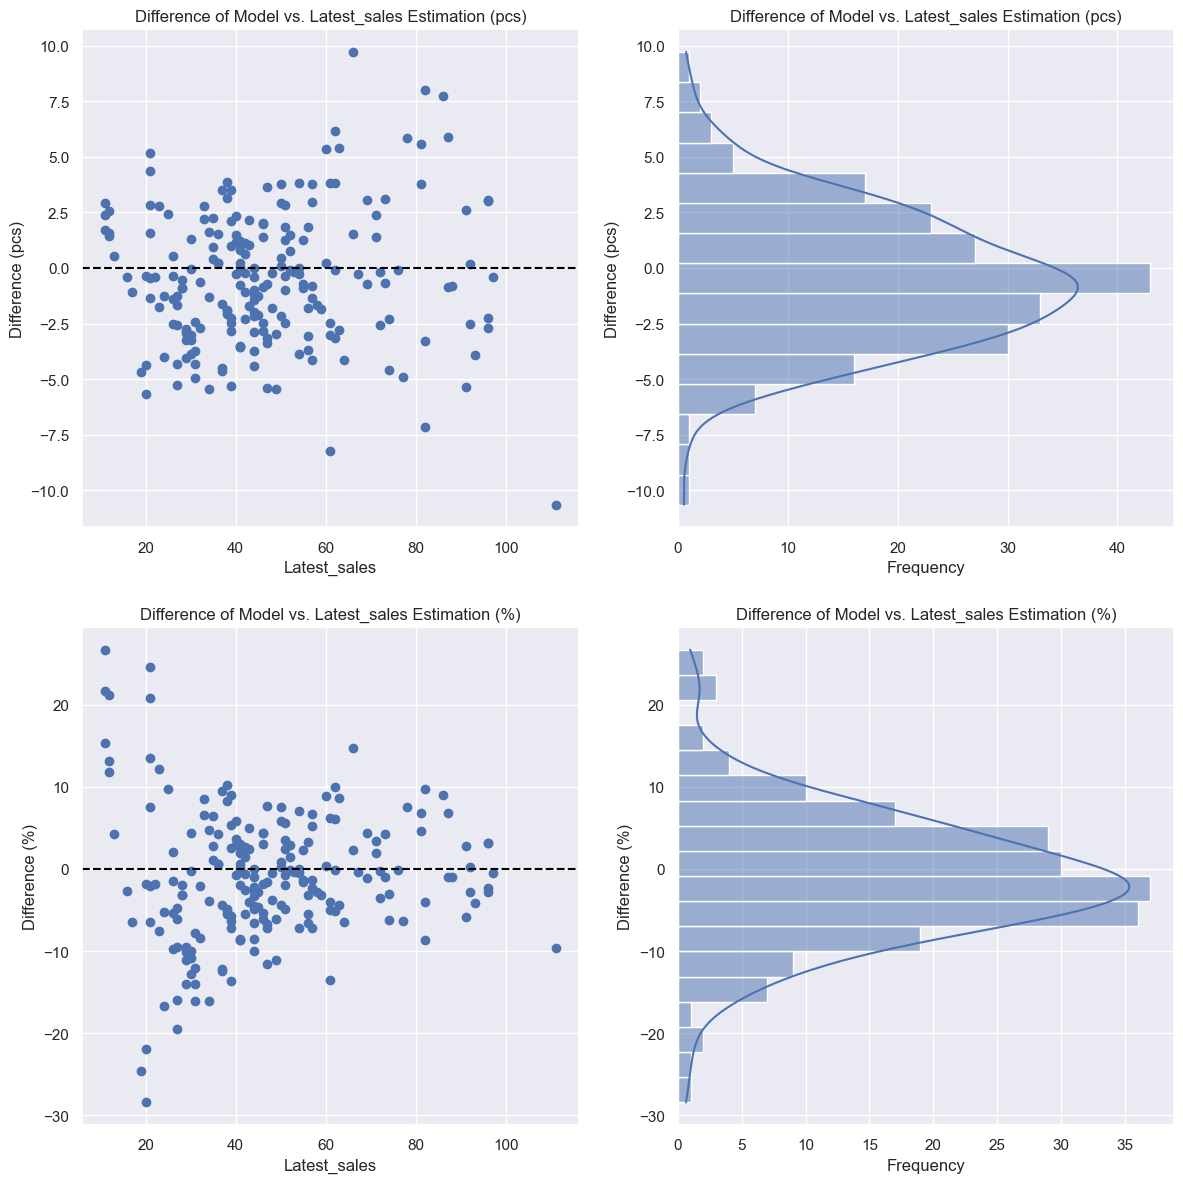

Mean Squared Error: 9.46
R-squared: 0.98
Mean Absolute Error: 2.45
Mean Absolute Percentage Error: 0.06

Diff. Model vs Latest_sales Cumulative %:


,Within +/- %,Cumulative %
1,5.0,51.43
2,10.0,83.33
3,15.0,93.33
4,20.0,96.19
5,25.0,99.05
6,30.0,100.00



Binned Percentages:


residual
(0.0, 5.0]      51.428571
(5.0, 10.0]     31.904762
(10.0, 15.0]    10.000000
(15.0, 20.0]     2.857143
(20.0, 25.0]     2.857143
(25.0, 30.0]     0.952381
Name: count, dtype: float64

In [37]:
# exclude rows with 0 in Latest_sales
data_exclude0 = data[data['Latest_sales'] != 0]

y_Latest_sales = data_exclude0['Latest_sales']
y_pred_Latest_sales = data_exclude0['Prediction']

# plot the Estimate analysis
plot_Estimate_analysis(y_Latest_sales, y_pred_Latest_sales, compare_X='Latest_sales', compare_Y='Model')
# calculate the metrics
calculate_metrics(y_Latest_sales, y_pred_Latest_sales)
create_residual_absolute(y_Latest_sales, y_pred_Latest_sales, compare_X='Latest_sales', compare_Y='Model', is_percentage=True)

# calc the difference
data['Diff_model_vs_Latest_sales'] = y_pred_Latest_sales - y_Latest_sales
# calc the difference ratio
data['DiffRatio_model_vs_Latest_sales'] = data['Diff_model_vs_Latest_sales'] / y_Latest_sales
# absolute difference
data['AbsDiff_model_vs_Latest_sales'] = abs(data['Diff_model_vs_Latest_sales'])
# absolute difference ratio
data['AbsDiffRatio_model_vs_Latest_sales'] = abs(data['DiffRatio_model_vs_Latest_sales'])

# save the data
data.to_csv(prediction_path, index=False)

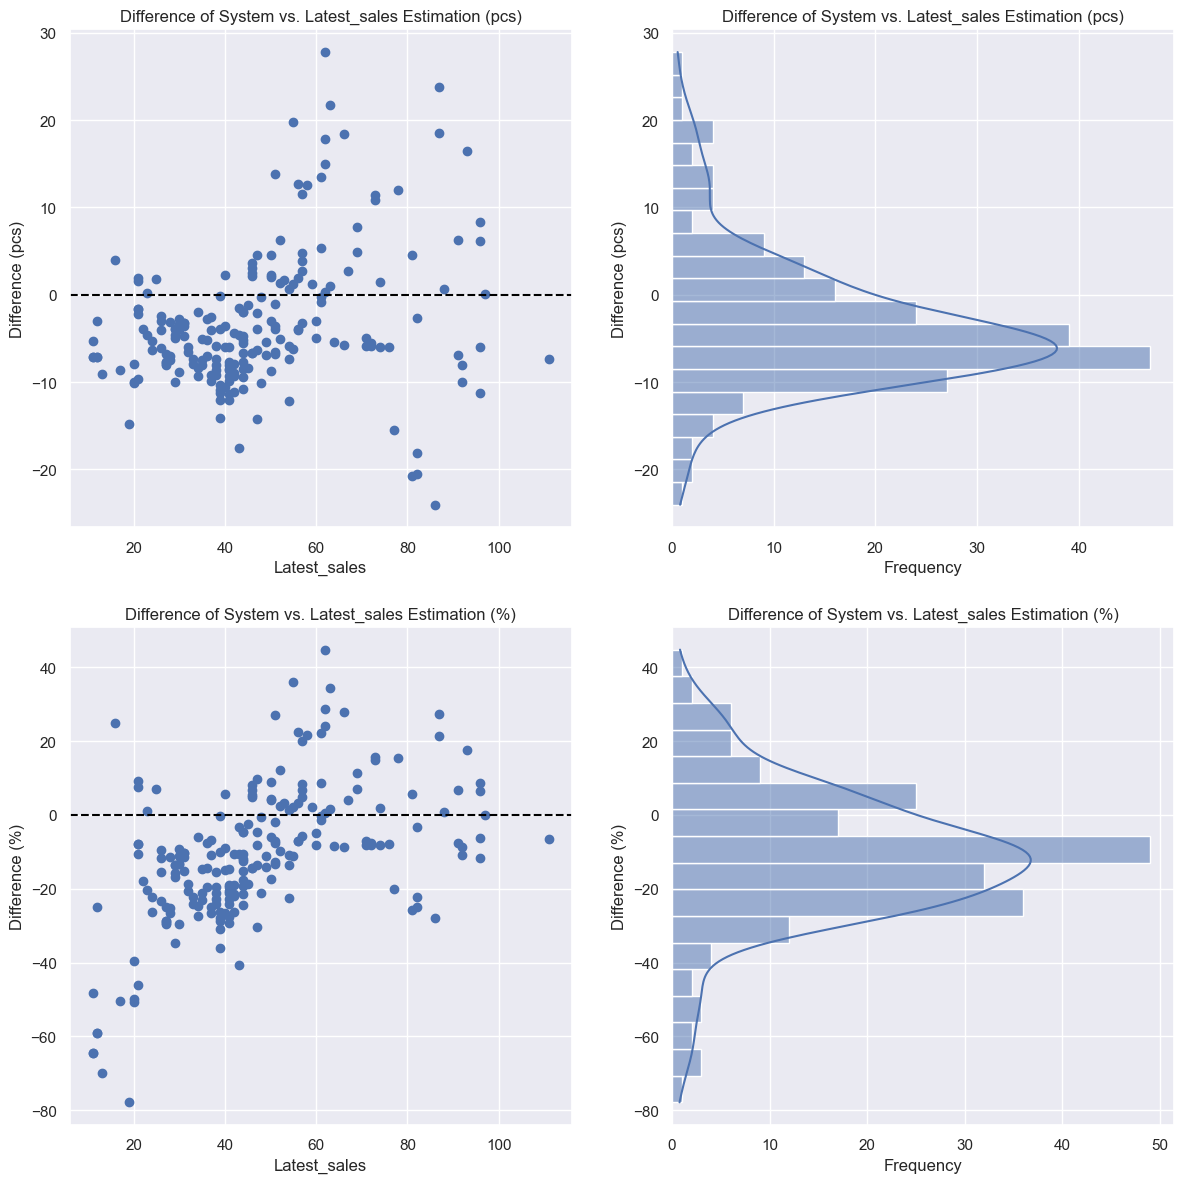

Mean Squared Error: 72.05
R-squared: 0.83
Mean Absolute Error: 6.94
Mean Absolute Percentage Error: 0.17

Diff. System vs Latest_sales Cumulative %:


,Within +/- %,Cumulative %
1,5.0,13.81
2,10.0,35.71
3,15.0,53.33
4,20.0,62.86
5,25.0,79.52
6,30.0,90.48
7,35.0,92.38
8,40.0,93.81
9,45.0,94.76
10,50.0,96.19



Binned Percentages:


residual
(0.0, 5.0]      13.809524
(5.0, 10.0]     21.904762
(10.0, 15.0]    17.619048
(15.0, 20.0]     9.523810
(20.0, 25.0]    16.666667
(25.0, 30.0]    10.952381
(30.0, 35.0]     1.904762
(35.0, 40.0]     1.428571
(40.0, 45.0]     0.952381
(45.0, 50.0]     1.428571
(50.0, 55.0]     0.952381
(55.0, 60.0]     0.952381
(60.0, 65.0]     0.952381
(65.0, 70.0]     0.476190
(70.0, 75.0]     0.000000
(75.0, 80.0]     0.476190
Name: count, dtype: float64

In [38]:
# exclude rows with 0 in Latest_sales
data_exclude0 = data[data['Latest_sales'] != 0]

y_Latest_sales = data_exclude0['Latest_sales']
y_system_Latest_sales = data_exclude0['System_calc']

# plot the Estimate analysis
plot_Estimate_analysis(y_Latest_sales, y_system_Latest_sales, compare_X='Latest_sales', compare_Y='System')
# calculate the metrics
calculate_metrics(y_Latest_sales, y_system_Latest_sales)
create_residual_absolute(y_Latest_sales, y_system_Latest_sales, compare_X='Latest_sales', compare_Y='System', is_percentage=True)

# calc the difference
data['Diff_system_vs_Latest_sales'] = y_system_Latest_sales - y_Latest_sales
# calc the difference ratio
data['DiffRatio_system_vs_Latest_sales'] = data['Diff_system_vs_Latest_sales'] / y_Latest_sales
# absolute difference
data['AbsDiff_system_vs_Latest_sales'] = abs(data['Diff_system_vs_Latest_sales'])
# absolute difference ratio
data['AbsDiffRatio_system_vs_Latest_sales'] = abs(data['DiffRatio_system_vs_Latest_sales'])

# save the data
data.to_csv(prediction_path, index=False)

From the above plots, it is clear to see that the system calculation is underestimating the demand. This might be caused by frequent stockout sales data affecting the formula, treating the extreme low sales as a valid data point.

While the model predicts the demand with residuals in a normal distribution behavior.

# 5. Result

**Performance Measure**

Comparing to the actual demand (lower % is better):
- Model prediction: 95% of estimation within +/- 18%
- System calculation: 95% of estimation within +/- 46%

In other words, % of estimation achieved a +/- 20% vs actual demand (higher % is better):
- Model prediction: 96.19%
- System calculation: 62.86%

**Any benefits of using machine learning model instead of manual ordering?**
- Increased demand prediction accuracy means better inventory control and service level → reduce the chance of heavy stock and stockout.
- The staff could free up manual ordering time to other high value tasks.

---